In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("/content/Real estate.csv")
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df.describe()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [ ]:
df1.shape

(414, 8)

In [ ]:
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [ ]:
df.tail()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
409,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5
413,2013.500,6.5,90.45606,9,24.97433,121.54310,63.9


In [ ]:
X = df[['X1 transaction date',
        'X2 house age',
        'X3 distance to the nearest MRT station',
        'X4 number of convenience stores',
        'X5 latitude',
        'X6 longitude']]

y = df['Y house price of unit area']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (414, 6)
Shape of y: (414,)


In [ ]:
import numpy as np

X_matrix = np.c_[np.ones(X.shape[0]), X]
Y_matrix = y.values.reshape(-1, 1)

print("Design Matrix X:")
print(X_matrix)

print("Target Matrix Y:")
print(Y_matrix)


Design Matrix X:
[[1.0000000e+00 2.0129170e+03 3.2000000e+01 ... 1.0000000e+01
  2.4982980e+01 1.2154024e+02]
 [1.0000000e+00 2.0129170e+03 1.9500000e+01 ... 9.0000000e+00
  2.4980340e+01 1.2153951e+02]
 [1.0000000e+00 2.0135830e+03 1.3300000e+01 ... 5.0000000e+00
  2.4987460e+01 1.2154391e+02]
 ...
 [1.0000000e+00 2.0132500e+03 1.8800000e+01 ... 7.0000000e+00
  2.4979230e+01 1.2153986e+02]
 [1.0000000e+00 2.0130000e+03 8.1000000e+00 ... 5.0000000e+00
  2.4966740e+01 1.2154067e+02]
 [1.0000000e+00 2.0135000e+03 6.5000000e+00 ... 9.0000000e+00
  2.4974330e+01 1.2154310e+02]]
Target Matrix Y:
[[ 37.9]
 [ 42.2]
 [ 47.3]
 [ 54.8]
 [ 43.1]
 [ 32.1]
 [ 40.3]
 [ 46.7]
 [ 18.8]
 [ 22.1]
 [ 41.4]
 [ 58.1]
 [ 39.3]
 [ 23.8]
 [ 34.3]
 [ 50.5]
 [ 70.1]
 [ 37.4]
 [ 42.3]
 [ 47.7]
 [ 29.3]
 [ 51.6]
 [ 24.6]
 [ 47.9]
 [ 38.8]
 [ 27. ]
 [ 56.2]
 [ 33.6]
 [ 47. ]
 [ 57.1]
 [ 22.1]
 [ 25. ]
 [ 34.2]
 [ 49.3]
 [ 55.1]
 [ 27.3]
 [ 22.9]
 [ 25.3]
 [ 47.7]
 [ 46.2]
 [ 15.9]
 [ 18.2]
 [ 34.7]
 [ 34.1]
 [ 53.

In [ ]:
df.isnull().sum()


,0
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


In [ ]:
df = df.drop(['No'], axis=1)
df.head()


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


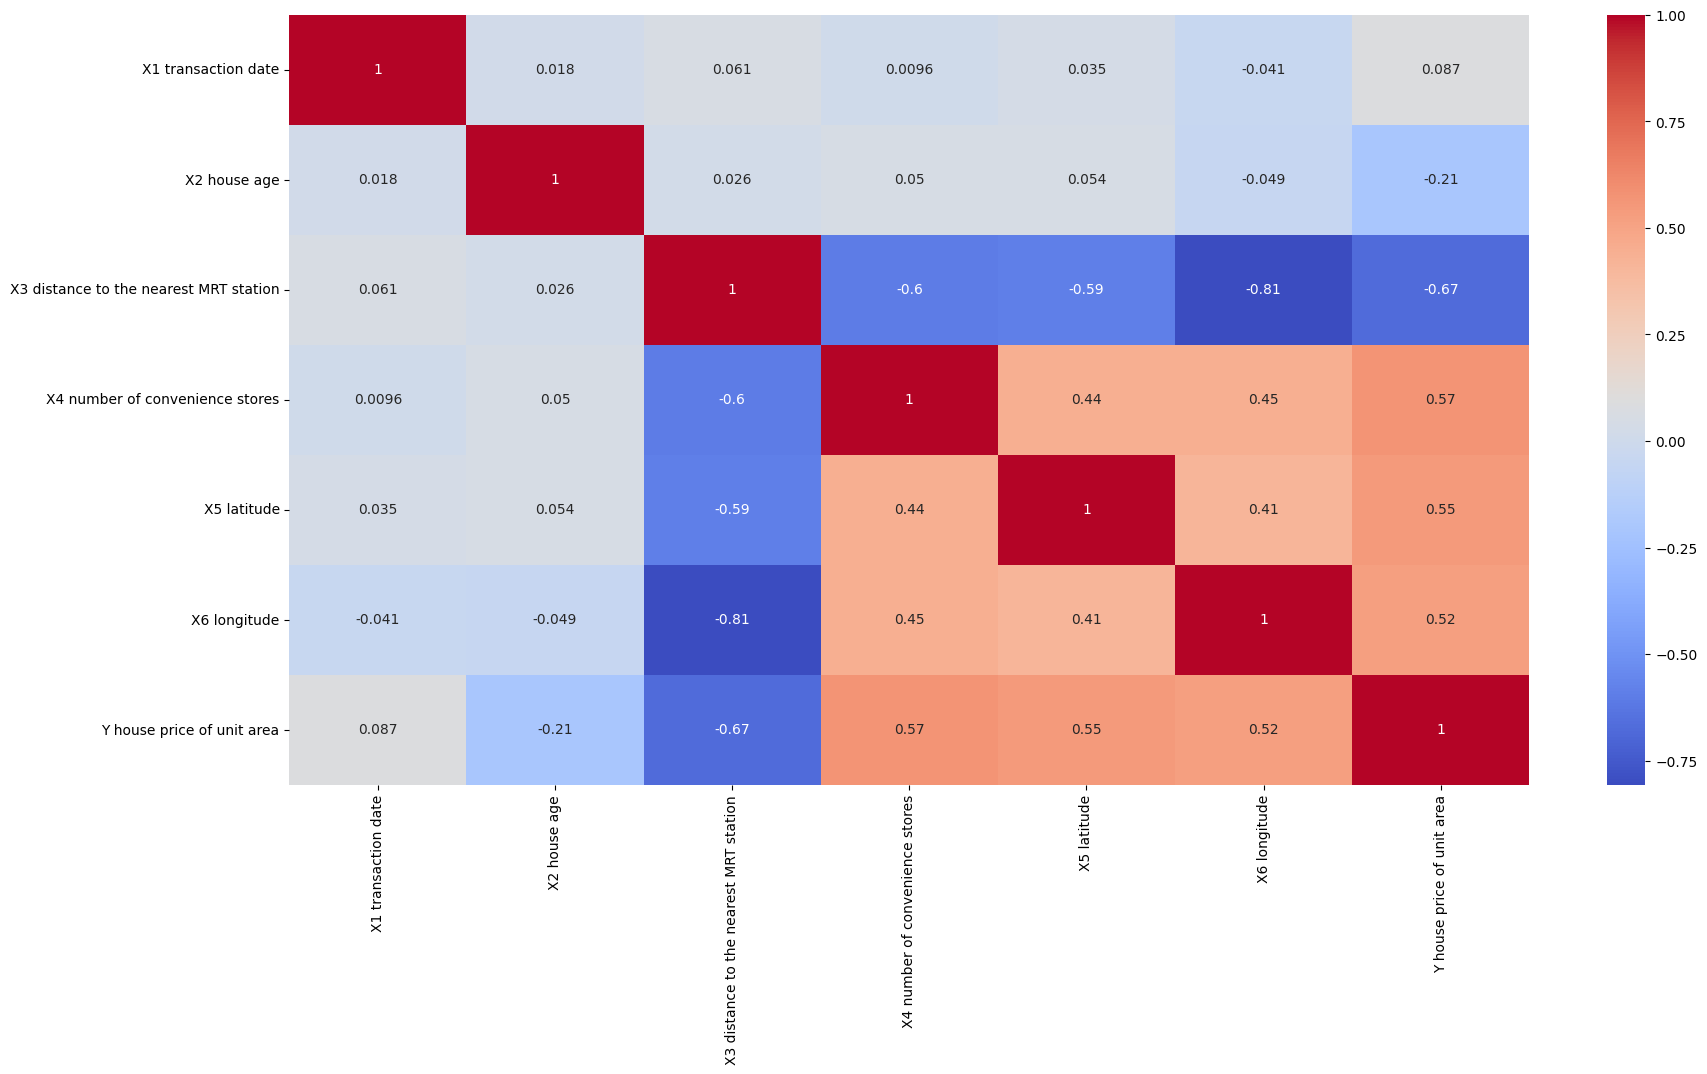

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()


In [ ]:
X = df.drop(['Y house price of unit area'], axis=1)
y = df['Y house price of unit area']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df


,Coefficient
X1 transaction date,1.736444
X2 house age,-2.943571
X3 distance to the nearest MRT station,-5.409977
X4 number of convenience stores,3.361895
X5 latitude,2.810247
X6 longitude,-0.039792


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
lasso = Lasso()
lasso.fit(X_train, y_train)

print("Lasso R2 Score:", lasso.score(X_test, y_test))


Lasso R2 Score: 0.5715903344021398


In [ ]:
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)

print("Decision Tree R2:", tree.score(X_test, y_test))


Decision Tree R2: 0.6246660279923066


In [ ]:
X_sm = sm.add_constant(X)
model_sm = sm.OLS(y, X_sm).fit()
model_sm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Y house price of unit area   R-squared:                       0.582
Model:                                    OLS   Adj. R-squared:                  0.576
Method:                         Least Squares   F-statistic:                     94.59
Date:                        Tue, 17 Feb 2026   Prob (F-statistic):           4.86e-74
Time:                                17:10:33   Log-Likelihood:                -1487.0
No. Observations:                         414   AIC:                             2988.
Df Residuals:                             407   BIC:                             3016.
Df Model:                                   6                                         
Covariance Type:                    nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                  -1.444e+04   6775.671     -2.131      0.034   -2.78e+04   -1117.421
X1 transaction date                        5.1462      1.557      3.305      0.001       2.085       8.207
X2 house age                              -0.2697      0.039     -7.000      0.000      -0.345      -0.194
X3 distance to the nearest MRT station    -0.0045      0.001     -6.250      0.000      -0.006      -0.003
X4 number of convenience stores            1.1333      0.188      6.023      0.000       0.763       1.503
X5 latitude                              225.4730     44.567      5.059      0.000     137.863     313.083
X6 longitude                             -12.4236     48.582     -0.256      0.798    -107.927      83.079
==============================================================================
Omnibus:                      231.634   Durbin-Watson:                   2.153
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3599.138
Skew:                           2.026   Prob(JB):                         0.00
Kurtosis:                      16.865   Cond. No.                     3.72e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.72e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
print("Mean:\n", df.mean())


Mean:
 No                                         207.500000
X1 transaction date                       2013.148971
X2 house age                                17.712560
X3 distance to the nearest MRT station    1083.885689
X4 number of convenience stores              4.094203
X5 latitude                                 24.969030
X6 longitude                               121.533361
Y house price of unit area                  37.980193
dtype: float64


In [ ]:
print("Median:\n", df.median())


Median:
 No                                         207.50000
X1 transaction date                       2013.16700
X2 house age                                16.10000
X3 distance to the nearest MRT station     492.23130
X4 number of convenience stores              4.00000
X5 latitude                                 24.97110
X6 longitude                               121.53863
Y house price of unit area                  38.45000
dtype: float64


In [ ]:
print("Mode:\n", df.mode().iloc[0])


Mode:
 No                                           1.00000
X1 transaction date                       2013.41700
X2 house age                                 0.00000
X3 distance to the nearest MRT station     289.32480
X4 number of convenience stores              0.00000
X5 latitude                                 24.97433
X6 longitude                               121.54348
Y house price of unit area                  24.70000
Name: 0, dtype: float64


In [ ]:
print("Variance:\n", df.var())


Variance:
 No                                        1.431750e+04
X1 transaction date                       7.950552e-02
X2 house age                              1.297887e+02
X3 distance to the nearest MRT station    1.592921e+06
X4 number of convenience stores           8.676334e+00
X5 latitude                               1.540130e-04
X6 longitude                              2.355360e-04
Y house price of unit area                1.851365e+02
dtype: float64


In [ ]:
print("Standard Deviation:\n", df.std())


Standard Deviation:
 No                                         119.655756
X1 transaction date                          0.281967
X2 house age                                11.392485
X3 distance to the nearest MRT station    1262.109595
X4 number of convenience stores              2.945562
X5 latitude                                  0.012410
X6 longitude                                 0.015347
Y house price of unit area                  13.606488
dtype: float64


In [ ]:
print("Covariance Matrix:\n")
print(df.cov())


Covariance Matrix:

                                                  No  X1 transaction date  \
No                                      14317.500000            -1.641671   
X1 transaction date                        -1.641671             0.079506   
X2 house age                              -44.723245             0.056372   
X3 distance to the nearest MRT station  -2049.850694            21.665566   
X4 number of convenience stores            -4.475787             0.008003   
X5 latitude                                -0.015012             0.000123   
X6 longitude                               -0.020309            -0.000178   
Y house price of unit area                -46.542615             0.335665   

                                        X2 house age  \
No                                        -44.723245   
X1 transaction date                         0.056372   
X2 house age                              129.788704   
X3 distance to the nearest MRT station    368.408249   
X4 num

In [ ]:
X = df.drop(['Y house price of unit area'], axis=1)
y = df['Y house price of unit area']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10
)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


In [ ]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)


Mean Squared Error (MSE): 68.99203960677328


In [ ]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error (RMSE):", rmse)


Root Mean Squared Error (RMSE): 8.306144689732612


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", mae)


Mean Absolute Error (MAE): 6.281993845415284


In [ ]:
r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)


R² Score: 0.5971389908484053


In [ ]:
n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("Adjusted R²:", adj_r2)


Adjusted R²: 0.5595386299942564


In [ ]:
print("\n------ Model Evaluation Summary ------")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("Adjusted R2:", adj_r2)



------ Model Evaluation Summary ------
MSE: 68.99203960677328
RMSE: 8.306144689732612
MAE: 6.281993845415284
R2: 0.5971389908484053
Adjusted R2: 0.5595386299942564


In [ ]:
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
cross_val_score(LinearRegression(), X, y, cv=cv)


array([0.65573664, 0.59752312, 0.44445133, 0.53790045, 0.62039363])